# Análisis Geoespacial

Daniel Núñez Vargas

In [1]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Para el análisis descriptivo inicial de contraste de asociación  
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran

# Librería para hacer la tramificación, agrupación y transformación WOE
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

# Librerías para el modelo Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.impute import SimpleImputer

from Funciones import * # Script donde se han incluido variedad de funciones personalizadas

## Carga de información

In [2]:
# Carga de los datos 
df_train_raw = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score.shp')
# Se cambian los nombres que se perdieron al guardar el archivo en formato .shp
df_train = cleanDataframe2(df_train_raw)
df_train.head(3)

,dc_dist,psa,date,hour,crime_description,id,time_of_day,day_of_week,week_of_year,month,...,mean_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,6236,Afternoon,Sunday,52,December,...,59711.0,19948,35.8,22.5,32.9,8.7,0.5465,0.385733,Low,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,9278,Afternoon,Sunday,52,December,...,65880.0,12823,28.3,20.5,45.4,5.6,0.4680,0.403961,Low,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,9381,Afternoon,Sunday,52,December,...,51112.0,20557,39.7,26.8,29.9,3.6,0.5170,0.528764,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


In [3]:
# Informacion general de los datos de entrenamiento
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 159762 entries, 0 to 159761
Data columns (total 34 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   dc_dist                 159762 non-null  int64         
 1   psa                     159711 non-null  object        
 2   date                    159762 non-null  datetime64[ms]
 3   hour                    159762 non-null  int32         
 4   crime_description       159762 non-null  object        
 5   id                      159762 non-null  int64         
 6   time_of_day             159762 non-null  object        
 7   day_of_week             159762 non-null  object        
 8   week_of_year            159762 non-null  int64         
 9   month                   159762 non-null  object        
 10  season                  159762 non-null  object        
 11  is_holiday              159762 non-null  bool          
 12  crimeType             

## Análisis por Área de Código Postal

In [4]:
# Se hace agrupamiento
aggregate_df_train_raw = df_train.groupby(['ZCTA', 'time_of_day']).agg({
    'geometry': 'first',
    'population' : 'first', 
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Se remueven NAs
aggregate_df_train = aggregate_df_train_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_train = gpd.GeoDataFrame(aggregate_df_train, geometry='geometry')
# Resumen 
aggregate_df_train.head(3)

# aggregate_df_train.to_csv("RiskScore_MediaZCTA_Train.csv")

,index,ZCTA,time_of_day,geometry,population,white_race,black_race,latino_race,asian_race,mean_income,median_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score
0,0,19004,Night,"POLYGON ((-75.24583 40.02155, -75.24562 40.023...",10668,8284,529,448,998,217722.0,143781.0,4216,11.3,5.4,37.4,45.8,0.5115,0.056829
1,1,19012,Night,"POLYGON ((-75.12187 40.05327, -75.12144 40.053...",6699,2792,2413,602,738,144838.0,117614.0,2237,5.4,10.6,46.1,37.8,0.4036,0.163235
2,2,19027,Afternoon,"POLYGON ((-75.15366 40.07214, -75.15332 40.072...",19170,8927,7207,1092,1231,136486.0,105190.0,8417,13.0,11.9,42.2,32.8,0.4608,0.036326


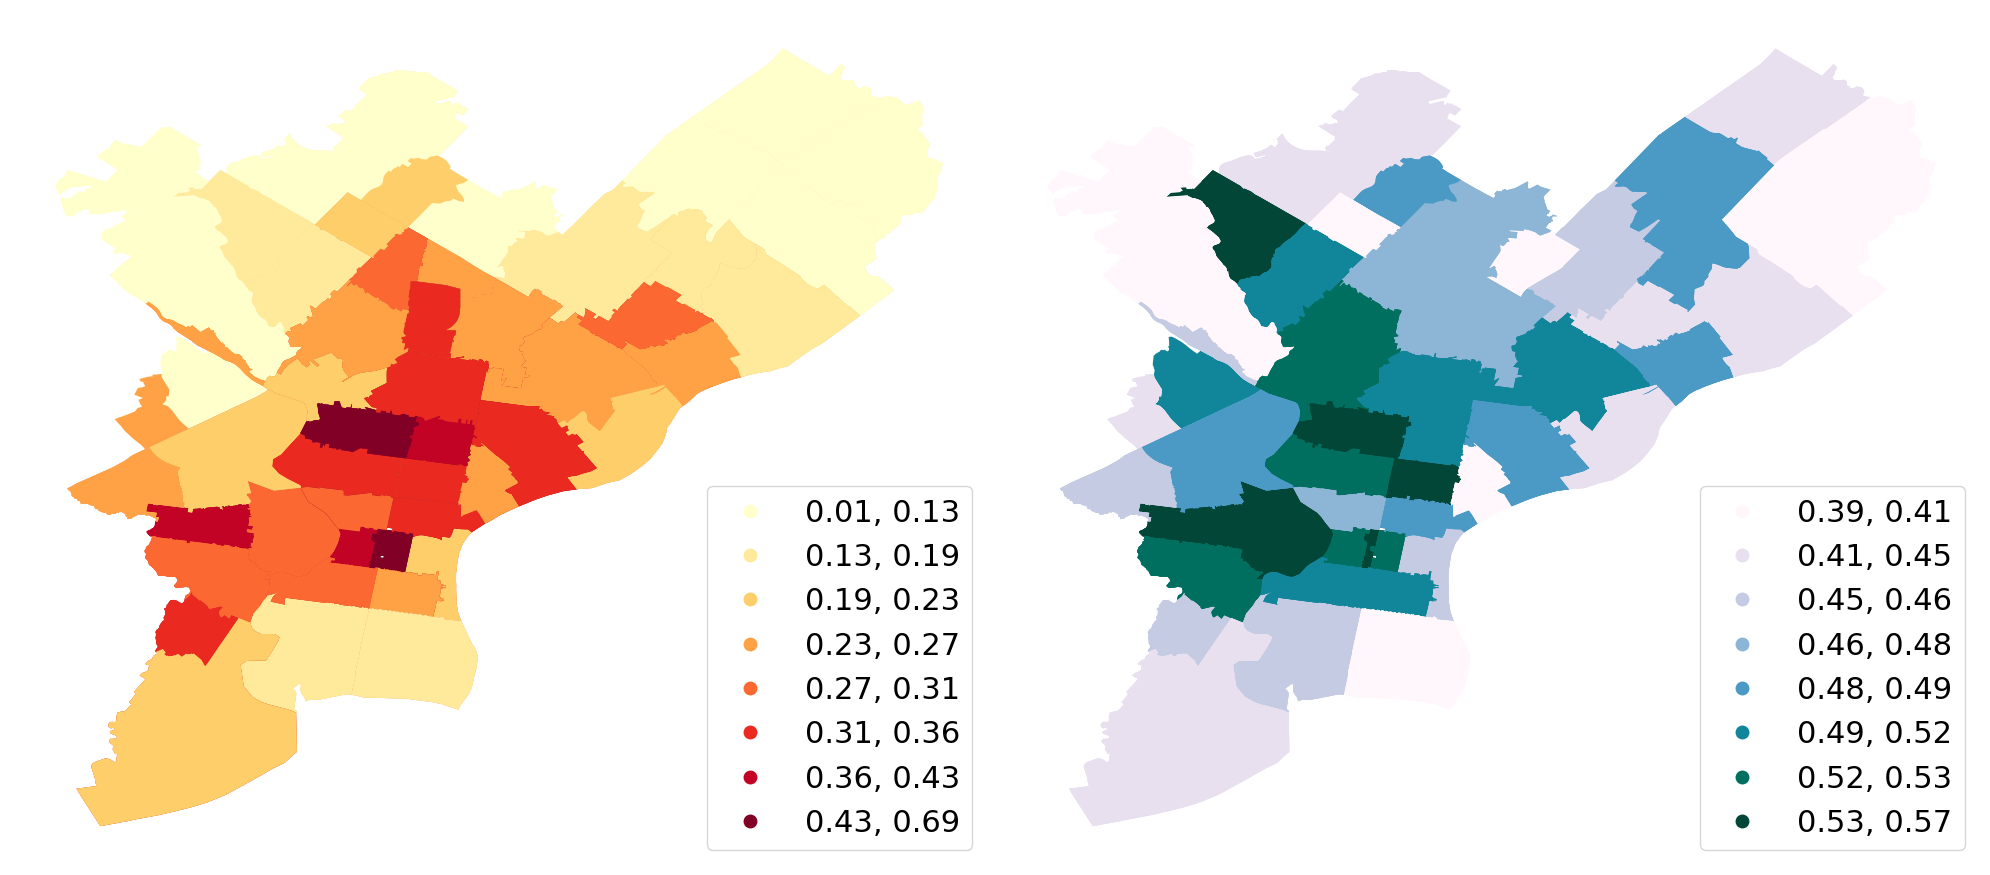

In [5]:
# Crear una figura con subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: Risk Score
map1 = aggregate_df_train.plot(column='risk_score', 
                              scheme='quantiles',
                              k=8, 
                              cmap='YlOrRd',
                              legend=True,
                              ax=axes[0],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[0].set_axis_off()
# axes[0].set_title('Distribución del Score de Riesgo', fontsize=14, pad=20)

# Mapa 2: Gini Index
map2 = aggregate_df_train.plot(column='GiniIndex', 
                              scheme='quantiles',
                              k=8, 
                              cmap='PuBuGn',
                              legend=True,
                              ax=axes[1],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[1].set_axis_off()
# axes[1].set_title('Distribución del Índice de Gini', fontsize=14, pad=20)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

# Matriz de pesos Espaciales

In [6]:
wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)
wq.transform = 'r'

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_26808\118154908.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)


In [7]:
print(wq.n)

150


In [8]:
# No hay islas
wq.islands

[]

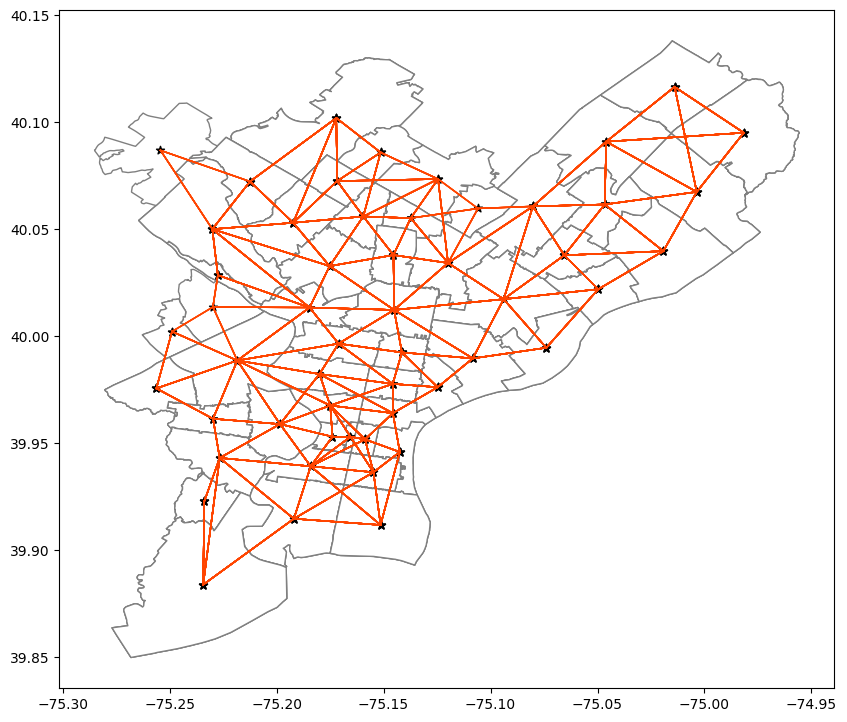

In [9]:
# Plot graph connections
ax = aggregate_df_train.plot(
        edgecolor="grey", facecolor="w",
        figsize=(10,10)
    )

wq.plot(
    aggregate_df_train,
    edge_kws=dict(linewidth=1, color="orangered"),
    node_kws=dict(marker="*"),
    ax=ax
)

plt.show()

## Retardo Espacial

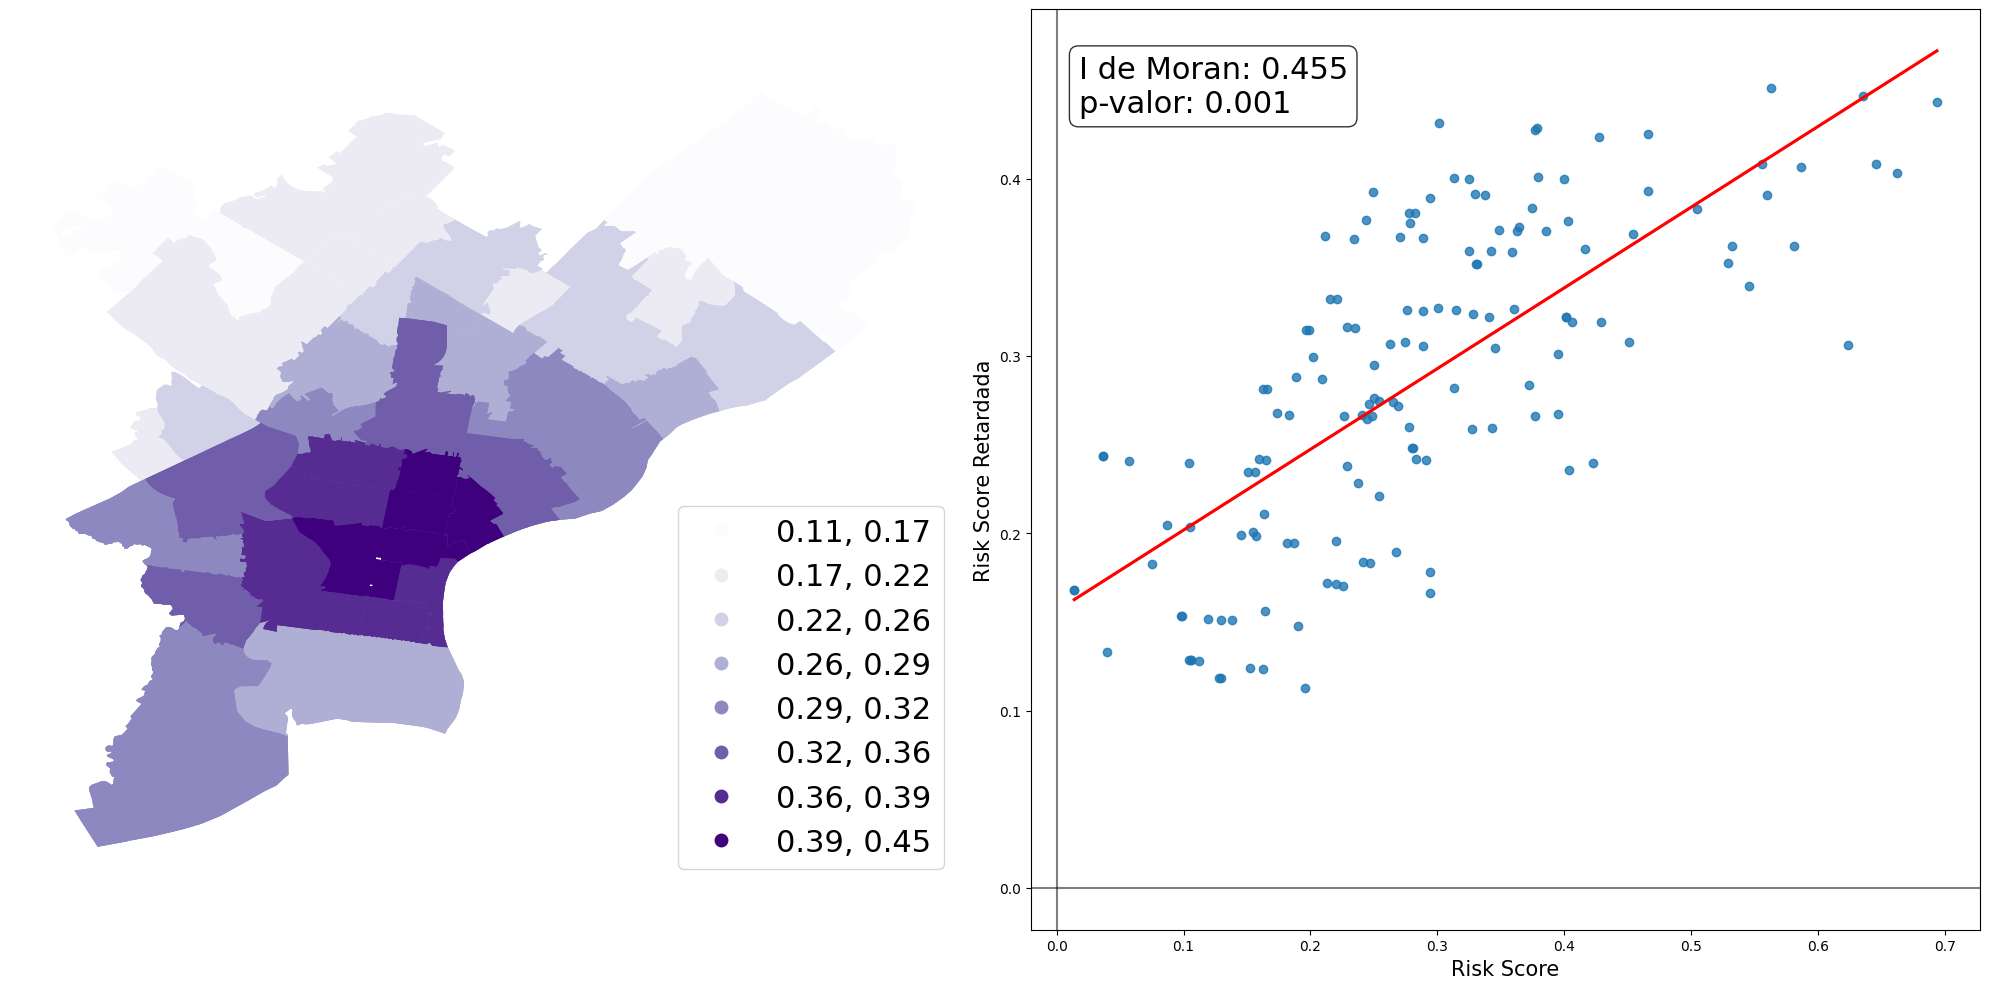

In [10]:
# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

# Crear una figura con subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa: Risk Score Retardada
map1 = aggregate_df_train.plot(column='risk_score_lag', 
                              scheme='quantiles',
                              k=8, 
                              cmap='Purples',
                              legend=True,
                              ax=axes[0],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[0].set_axis_off()
# axes[0].set_title('Risk Score con Retardo Espacial', fontsize=14, pad=20)

# Diagrama de Moran con estadísticas
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
    ax=axes[1]
)
axes[1].axvline(0, c="k", alpha=0.5)
axes[1].axhline(0, c="k", alpha=0.5)

# Calcular la I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)

# Añadir las estadísticas al gráfico
# Añadir las estadísticas dentro del gráfico
axes[1].text(0.05, 0.95, f"I de Moran: {moran.I:.3f}\np-valor: {moran.p_sim:.3f}", 
            transform=axes[1].transAxes, fontsize=22, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
axes[1].set_xlabel('Risk Score', fontsize=15)
axes[1].set_ylabel('Risk Score Retardada', fontsize=15)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

## Correlación Local

In [11]:
#Correlación Espacial Local
lisa = esda.moran.Moran_Local(aggregate_df_train["risk_score"], wq, seed=42)

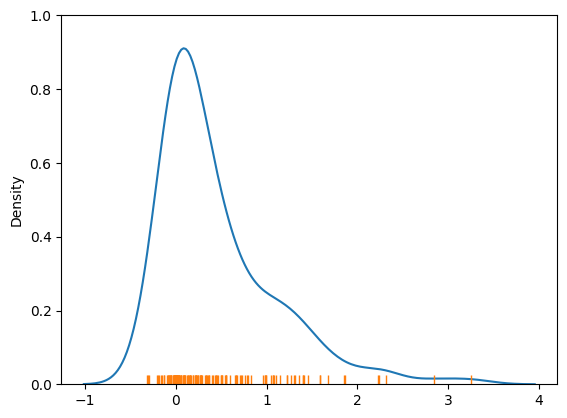

In [12]:
#Correlación Espacial Local
#Representación del Indice de Moran Local (Is)
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);

In [13]:
# # Set up figure and axes
# f, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
# # Make the axes accessible with single indexing
# axs = axs.flatten()

# # Subplot 1 #
# # Choropleth of local statistics
# # Grab first axis in the figure
# ax = axs[0]
# # Assign new column with local statistics on-the-fly
# aggregate_df_train.assign(
#     Is=lisa.Is
#     # Plot choropleth of local statistics
# ).plot(
#     column="Is",
#     cmap="PuBuGn",
#     scheme="quantiles",
#     k=5,
#     edgecolor="white",
#     linewidth=0.1,
#     alpha=0.75,
#     legend=True,
#     ax=ax,
# )

# # Subplot 2 #
# # Quadrant categories
# # Grab second axis of local statistics
# ax = axs[1]
# # Plot Quandrant colors (note to ensure all polygons are assigned a
# # quadrant, we "trick" the function by setting significance level to
# # 1 so all observations are treated as "significant" and thus assigned
# # a quadrant color
# esdaplot.lisa_cluster(lisa, aggregate_df_train, p=1, ax=ax)

# # Subplot 3 #
# # Significance map
# # Grab third axis of local statistics
# ax = axs[2]
# #
# # Find out significant observations
# labels = pd.Series(
#     1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
#     index=aggregate_df_train.index  # Use the index in the original data
#     # Recode 1 to "Significant and 0 to "Non-significant"
# ).map({1: "Significant", 0: "Non-Significant"})
# # Assign labels to `db` on the fly
# aggregate_df_train.assign(
#     cl=labels
#     # Plot choropleth of (non-)significant areas
# ).plot(
#     column="cl",
#     categorical=True,
#     k=2,
#     cmap="Paired",
#     linewidth=0.1,
#     edgecolor="white",
#     legend=True,
#     ax=ax,
# )


# # Subplot 4 #
# # Cluster map
# # Grab second axis of local statistics
# ax = axs[3]
# # Plot Quandrant colors In this case, we use a 5% significance
# # level to select polygons as part of statistically significant
# # clusters
# esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax)

# # Figure styling #
# # Set title to each subplot
# for i, ax in enumerate(axs.flatten()):
#     ax.set_axis_off()
#     ax.set_title(
#         [
#             "Local Statistics",
#             "Scatterplot Quadrant",
#             "Statistical Significance",
#             "Moran Cluster Map",
#         ][i],
#         y=0,
#     )
# # Tight layout to minimise in-betwee white space
# # f.tight_layout()

# # Display the figure
# plt.show()

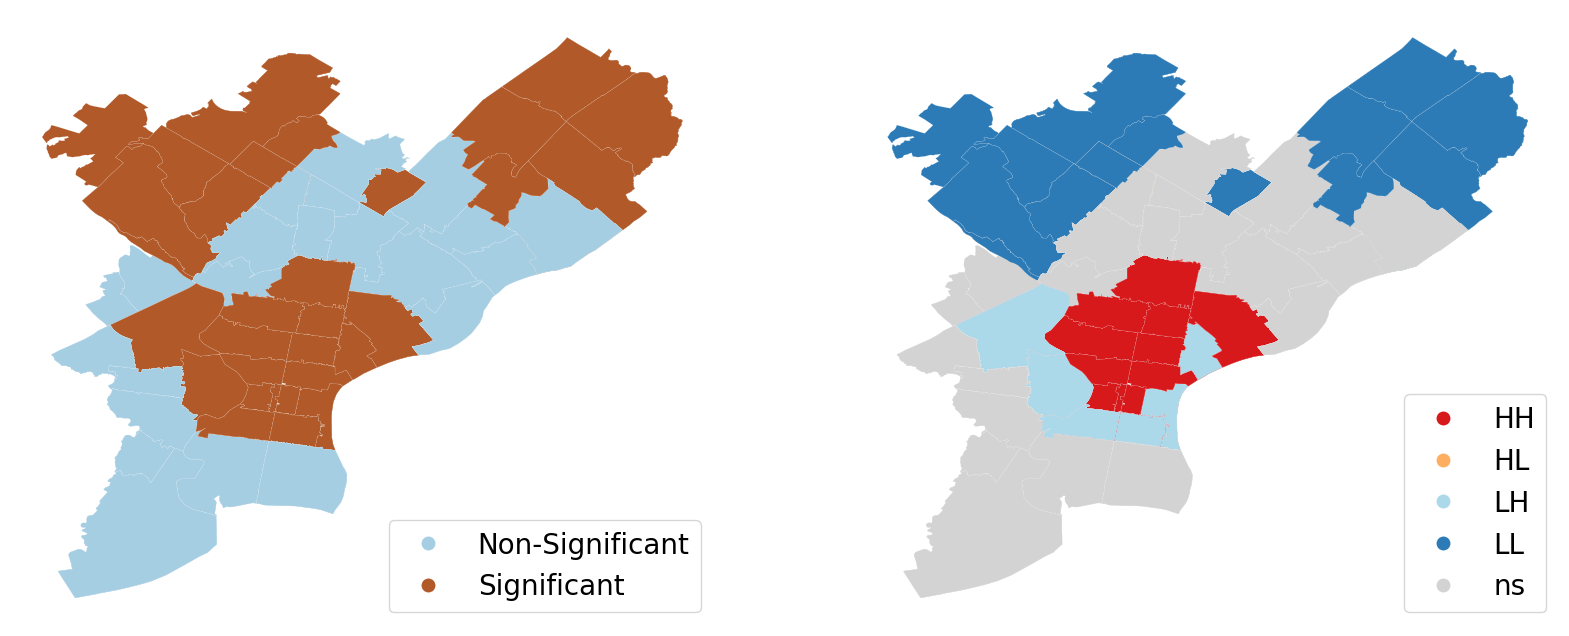

In [14]:
# Set up figure and axes
f, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Significance map
# Grab third axis of local statistics
ax = axs[0]
#
# Find out significant observations
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=aggregate_df_train.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
aggregate_df_train.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
    legend_kwds={'loc': 'lower right', 'fontsize':'20'}
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[1]
# Plot Quandrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax, legend_kwds={'loc': 'lower right', 'fontsize':'20'})

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    # ax.set_title(
    #     [
    #         "Significancia Estadística por Área Postal",
    #         "Cluster de Moran",
    #     ][i],
    #     y=0,
    # )
# Tight layout to minimise in-betwee white space
# f.tight_layout()

# Display the figure
plt.show()

In [15]:
# Assign pseudo P-values to `gdfm`
aggregate_df_train["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
aggregate_df_train["sig"] = sig

# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
aggregate_df_train["labels"] = pd.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=aggregate_df_train.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
aggregate_df_train["labels"].value_counts()

labels
Non-Significant    60
HH                 41
LL                 36
LH                 10
HL                  3
Name: count, dtype: int64

In [16]:
# Se une la información agregada del análisis espacial a la base de datos original 
df_train_with_lag = df_train.merge(
    right=aggregate_df_train[['ZCTA', 'time_of_day', 'risk_score_lag', 'sig', 'labels']],
    on=['ZCTA', 'time_of_day'],
    how='left'
)

In [17]:
df_train_with_lag.head(3)

,dc_dist,psa,date,hour,crime_description,id,time_of_day,day_of_week,week_of_year,month,...,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry,risk_score_lag,sig,labels
0,16,1,2023-12-31,19,Thefts,6236,Afternoon,Sunday,52,December,...,22.5,32.9,8.7,0.5465,0.385733,Low,"POLYGON ((-75.21367 39.96003, -75.21204 39.959...",0.370328,1.0,HH
1,14,1,2023-12-31,19,Theft from Vehicle,9278,Afternoon,Sunday,52,December,...,20.5,45.4,5.6,0.4680,0.403961,Low,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518...",0.235866,1.0,HL
2,25,1,2023-12-31,19,Other Assaults,9381,Afternoon,Sunday,52,December,...,26.8,29.9,3.6,0.5170,0.528764,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008...",0.352109,1.0,HH


# Modelado

## Modelo sin componente espacial

In [18]:
df_train.head(3)

,dc_dist,psa,date,hour,crime_description,id,time_of_day,day_of_week,week_of_year,month,...,mean_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,6236,Afternoon,Sunday,52,December,...,59711.0,19948,35.8,22.5,32.9,8.7,0.5465,0.385733,Low,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,9278,Afternoon,Sunday,52,December,...,65880.0,12823,28.3,20.5,45.4,5.6,0.4680,0.403961,Low,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,9381,Afternoon,Sunday,52,December,...,51112.0,20557,39.7,26.8,29.9,3.6,0.5170,0.528764,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


In [19]:
train = aggregate_df_train.copy()

In [20]:
#Regresión MCO
m1 = spreg.OLS(
    # Dependent variable
    train[["risk_score"]].values,
    # Independent variables
    train[["GiniIndex"]].values,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex"]
)

print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :  risk_score                Number of Observations:         150
Mean dependent var  :      0.2848                Number of Variables   :           2
S.D. dependent var  :      0.1411                Degrees of Freedom    :         148
R-squared           :      0.2698
Adjusted R-squared  :      0.2649
Sum squared residual:     2.16729                F-statistic           :     54.6979
Sigma-square        :       0.015                Prob(F-statistic)     :   9.672e-12
S.E. of regression  :       0.121                Log likelihood        :     104.946
Sigma-square ML     :       0.014                Akaike info criterion :    -205.892
S.E of regression ML:      0.1202                Schwarz criterion     :    -199.871

------------------------------------------------------------

In [21]:
# Verificar dimensiones
print(f"Dimensiones de wq: {wq.n}")
print(f"Dimensiones de residuos: {len(m1.u)}")
print(f"Dimensiones de train: {len(train)}")

Dimensiones de wq: 150
Dimensiones de residuos: 150
Dimensiones de train: 150


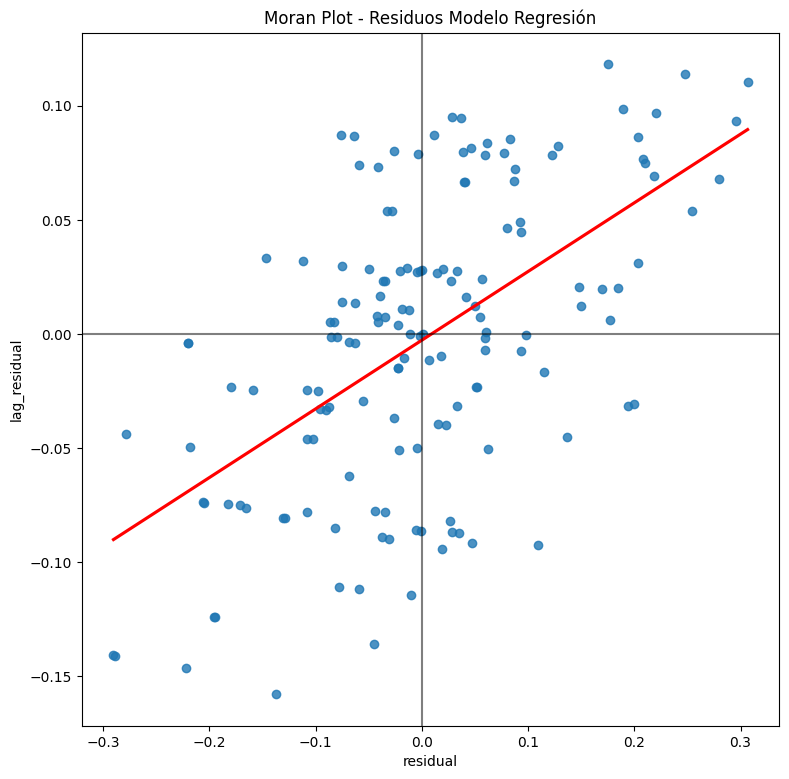

In [22]:
# Create column with residual values from m1
train["residual"] = m1.u
train["lag_residual"] = weights.spatial_lag.lag_spatial(wq, m1.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="residual",
    y="lag_residual",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión")
plt.show()

In [23]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(train["residual"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.301
p-valor: 0.001


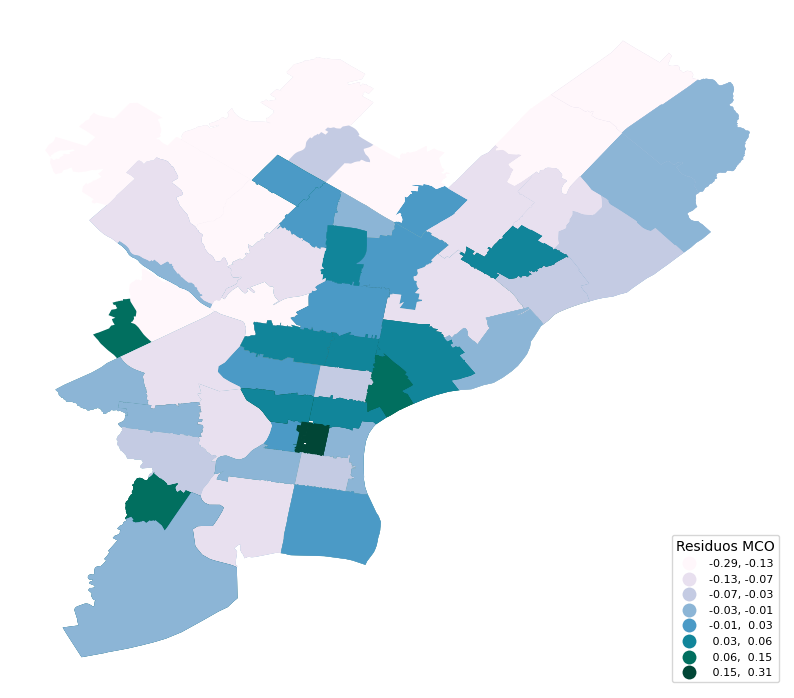

In [24]:
# representación de los residuos MCO  retardada
map=train.plot(column='residual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos MCO'} 
)
map.set_axis_off()

## Modelo Espacial

In [26]:
train.columns

Index(['index', 'ZCTA', 'time_of_day', 'geometry', 'population', 'white_race',
       'black_race', 'latino_race', 'asian_race', 'mean_income',
       'median_income', 'total_households', 'household_25k_or_less',
       'household_25k_to_50k', 'household_50k_to_150k',
       'household_150k_or_more', 'GiniIndex', 'risk_score', 'risk_score_lag',
       'p-sim', 'sig', 'labels', 'residual', 'lag_residual'],
      dtype='object')

In [27]:
# Reordenar para que Morning sea la primera categoría alfabéticamente
train["time_of_day_reordered"] = train["time_of_day"].replace({
    'Afternoon': 'B_Afternoon',  # B para que sea segunda
    'Morning': 'A_Morning',      # A para que sea primera (se elimina)
    'Night': 'C_Night'           # C para que sea tercera
})

# Crear dummies (ahora Morning se eliminará)
dummies = pd.get_dummies(train["time_of_day_reordered"], prefix="time", drop_first=True)

# Limpiar nombres de columnas
dummies.columns = [col.replace('time_B_', 'time_').replace('time_C_', 'time_') 
                   for col in dummies.columns]

# Concatenar con tus features
X = pd.concat([train[["GiniIndex"]], dummies], axis=1).astype(float).values
y = train[["risk_score"]].values

In [28]:
# Concatenar con tus features
# X = train[["GiniIndex"]].astype(float).values
# y = train[["risk_score"]].values

In [29]:
# (Modelo autoregresivo espacial - estimado por MC2E)
mLag = spreg.GM_Lag(    
    # Dependent variable
    y=y,
    # Independent variables
    x=X,
    # Spatial weights matrix
    w= wq,
    robust='white',
    # Numero de retardos
    w_lags=3,
    #para el modelo de durbin slx_lags >0
    # slx_lags = 1, 
    #diagnósitico de correlación espacial
    spat_diag=True,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex", 'Afternoon', 'Night'], #, 'time_Afternoon', 'time_Night' 
    name_w=" Contiguidad Reina",
    name_ds=" Índice de Criminalidad en Filadelfia"
    
)

print(mLag.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            : Índice de Criminalidad en Filadelfia
Weights matrix      : Contiguidad Reina
Dependent Variable  :  risk_score                Number of Observations:         150
Mean dependent var  :      0.2848                Number of Variables   :           5
S.D. dependent var  :      0.1411                Degrees of Freedom    :         145
Pseudo R-squared    :      0.6968
Spatial Pseudo R-squared:  0.4073

White Standard Errors
------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.37500         0.06504        -5.76558         0.00000
           GiniIndex         0.73536         0.13997         5.25370      

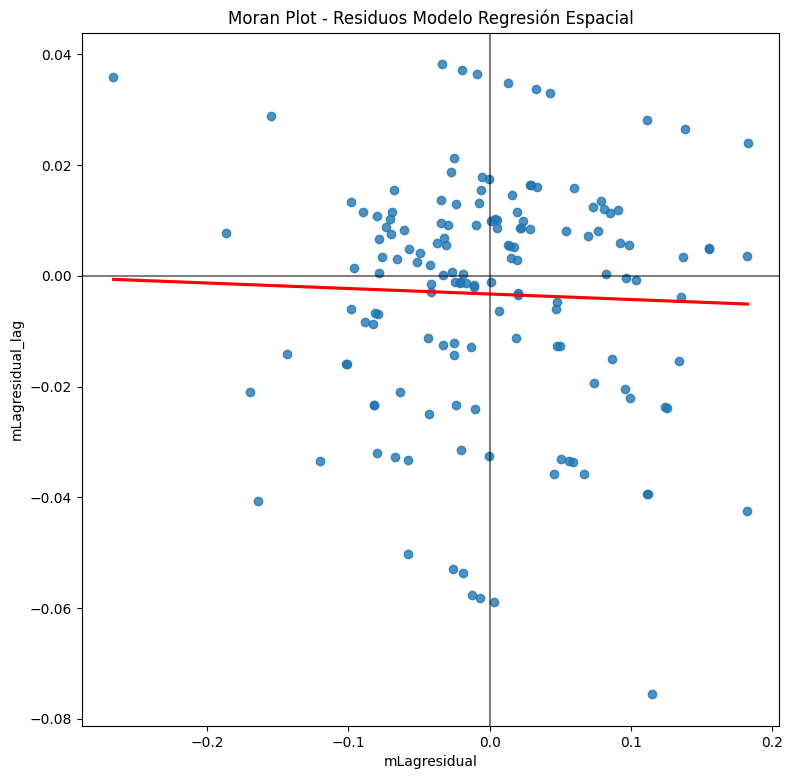

In [30]:
# Create column with residual values from m1
train["mLagresidual"] = mLag.u
train["mLagresidual_lag"] = weights.spatial_lag.lag_spatial(wq, mLag.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="mLagresidual",
    y="mLagresidual_lag",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión Espacial")
plt.show()

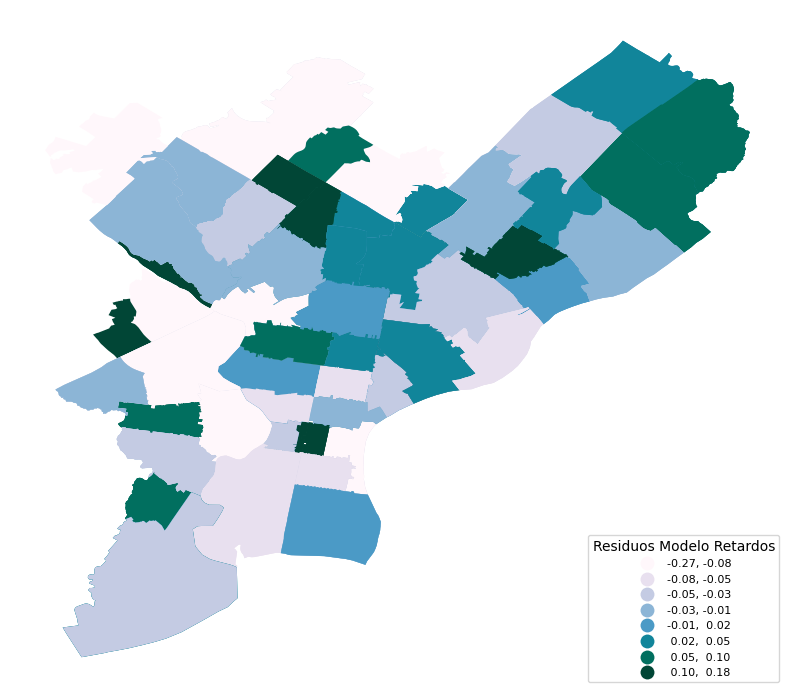

In [31]:
# representación de los residuos Modelo Retardado
map=train.plot(column='mLagresidual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos Modelo Retardos'} 
)
map.set_axis_off() 


### Predicciones

In [32]:
df_test = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp'))
df_test = df_test[(df_test['date'] >= '2025-01-01')]

DataSourceError: ../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp: No such file or directory

In [ ]:
# Se hace agrupamiento
aggregate_df_test_raw = df_test.groupby(['ZCTA', 'time_of_day']).agg({
    'geometry': 'first',
    'population' : 'first',
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# aggregate_df_test_raw.to_csv("RiskScore_MediaZCTA_Test.csv")

# Se remueven NAs
aggregate_df_test = aggregate_df_test_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_test = gpd.GeoDataFrame(aggregate_df_test, geometry='geometry')

In [ ]:
test = aggregate_df_test.copy()

In [ ]:
# Crear matriz de pesos de contigüidad reina para validación
wq_test = weights.Queen.from_dataframe(test)

# Normalizar (como hiciste en training)
wq_test.transform = 'r'

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_20208\3216524482.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq_test = weights.Queen.from_dataframe(test)


In [ ]:
# Reordenar para que Morning sea la primera categoría alfabéticamente
test["time_of_day_reordered"] = test["time_of_day"].replace({
    'Afternoon': 'B_Afternoon',  # B para que sea segunda
    'Morning': 'A_Morning',      # A para que sea primera (se elimina)
    'Night': 'C_Night'           # C para que sea tercera
})

# Crear dummies (ahora Morning se eliminará)
dummies = pd.get_dummies(test["time_of_day_reordered"], prefix="time", drop_first=True)

# Limpiar nombres de columnas
dummies.columns = [col.replace('time_B_', 'time_').replace('time_C_', 'time_') 
                   for col in dummies.columns]

# Concatenar con tus features
X_val = pd.concat([test[["GiniIndex"]], dummies], axis=1).astype(float).values
y_val = test[["risk_score"]].values

In [ ]:
# Concatenar con tus features
X_val = test[["GiniIndex"]].astype(float).values
y_val = test[["risk_score"]].values

In [ ]:
betas = np.array(mLag.betas).flatten()
intercept = betas[0]
coefs = betas[1:-1]   # todas las covariables excepto rho
rho = betas[-1]

# Construcción de Xβ con todas las variables de una vez
Xbeta = intercept + X_val.dot(coefs)

In [ ]:
# 3) Matriz de pesos espaciales (misma del entrenamiento)
W_test, ids = wq_test.full()
n = W_test.shape[0]

In [ ]:
# 4) Resolver el sistema (I - rho W) y = Xβ
I = np.eye(n)
M = I - rho * W_test   
Xbeta_vec = Xbeta.reshape(-1, 1)

In [ ]:
try:
    y_val_pred = np.linalg.solve(M, Xbeta_vec).flatten()
except np.linalg.LinAlgError:
    print("Advertencia: (I - rho W) es singular; usando pseudo-inversa")
    y_val_pred = np.linalg.pinv(M).dot(Xbeta_vec).flatten()

In [ ]:
y_val.flatten()

array([0.05682926, 0.02109947, 0.25471186, 0.19218177, 0.7587997 ,
       0.76024964, 0.63499694, 0.74624495, 0.48821799, 0.41374821,
       0.48791564, 0.29738396, 0.33525972, 0.38803392, 0.2841515 ,
       0.23670744, 0.74805503, 0.72321196, 0.67707929, 0.47003671,
       0.47003671, 0.28097725, 0.19500685, 0.19099551, 0.23634661,
       0.1481962 , 0.15851916, 0.17422304, 0.12098253, 0.11065287,
       0.1879903 , 0.1259101 , 0.12027314, 0.23769961, 0.14889354,
       0.13497324, 0.27299665, 0.18262999, 0.16592006, 0.46570673,
       0.29832984, 0.31191986, 0.6870159 , 0.42893859, 0.44817336,
       0.58011962, 0.38067145, 0.38716067, 0.64177215, 0.41516209,
       0.40219477, 0.51165683, 0.36801833, 0.32126374, 0.45997037,
       0.36006383, 0.28906329, 0.3836211 , 0.25581852, 0.27096639,
       0.35174126, 0.29198034, 0.26994632, 0.19570748, 0.12984766,
       0.10267589, 0.38883917, 0.25368573, 0.21823446, 0.56605033,
       0.43575555, 0.3434253 , 0.46123267, 0.27460716, 0.26215

In [ ]:
y_val_pred

array([ 0.5219711 ,  0.09070251,  0.37460921,  0.39415388,  0.55422393,
        0.45354484,  0.44846939,  0.58194803,  0.48296345,  0.47797343,
        0.60464336,  0.50311794,  0.49799984,  0.45106671,  0.35208212,
        0.3470921 ,  0.52622301,  0.42488152,  0.41977268,  0.3274206 ,
        0.22892061,  0.1970417 ,  0.09663   ,  0.09156803,  0.00948098,
       -0.09063355, -0.09568053,  0.09111085, -0.00930085, -0.01436281,
        0.00829213, -0.08899549, -0.09389996,  0.47163263,  0.37604444,
        0.37122564,  0.42912946,  0.32901493,  0.32396795,  0.33553153,
        0.235417  ,  0.23037002,  0.58177401,  0.48085305,  0.47576542,
        0.56097912,  0.46005816,  0.45497052,  0.49284013,  0.39149864,
        0.38638981,  0.32757727,  0.22605185,  0.22093374,  0.41538364,
        0.31639905,  0.31140903,  0.35749559,  0.26020797,  0.2553035 ,
        0.44185103,  0.34626284,  0.34144404,  0.38975778,  0.28934608,
        0.28428412,  0.52581488,  0.42467408,  0.41957536,  0.51

RMSE: 0.1508
R²:   0.1787


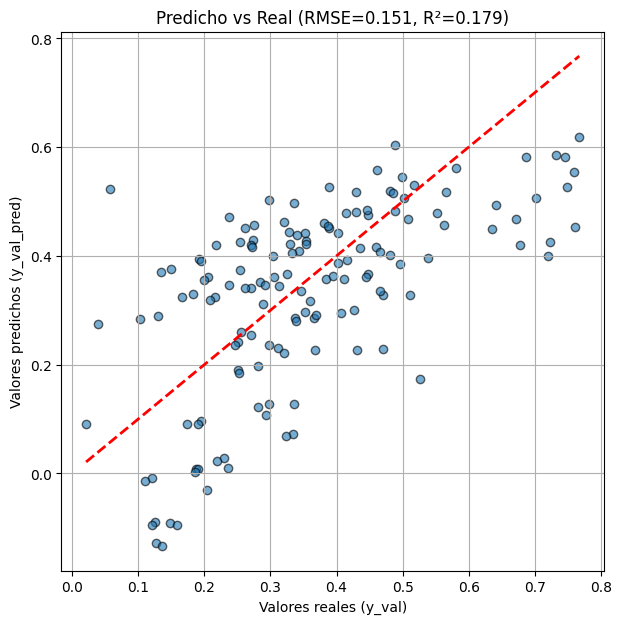

In [ ]:
# 1) Valores reales y predichos
y_true = y_val.flatten()
y_pred = y_val_pred

# 2) Métricas
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# 3) Scatter plot Predicho vs Real
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Valores reales (y_val)")
plt.ylabel("Valores predichos (y_val_pred)")
plt.title(f"Predicho vs Real (RMSE={rmse:.3f}, R²={r2:.3f})")
plt.grid(True)
plt.show()

In [ ]:
df_resultados = pd.DataFrame({
    'y_true': y_val.flatten(),
    'y_pred': y_val_pred
})

df_resultados.head(100)

,y_true,y_pred
0,0.056829,0.403723
1,0.021099,0.219854
2,0.254712,0.367312
3,0.192182,0.409798
4,0.634997,0.461989
...,...,...
95,0.388034,0.337742
96,0.236707,0.337742
97,0.236707,0.337742
98,0.236707,0.337742


# Selección de Features para modelo ML

In [52]:
train = df_train_with_lag.dropna().copy()

### Variable Respuesta (Risk Score) 

In [54]:
train['risk_score'].describe()

count    159762.000000
mean          0.350240
std           0.133802
min           0.013821
25%           0.253874
50%           0.342340
75%           0.406398
max           0.693666
Name: risk_score, dtype: float64

<Axes: xlabel='risk_score_lag', ylabel='risk_score'>

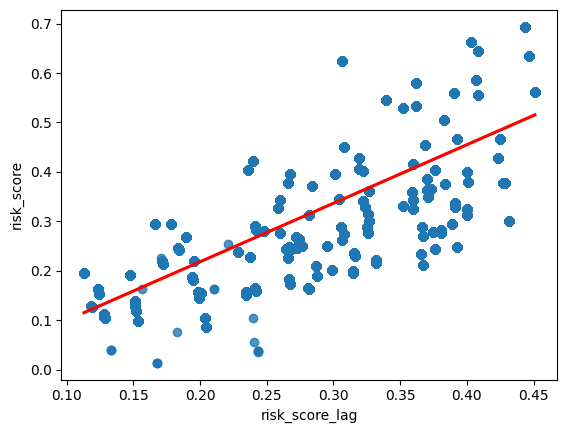

In [55]:
sns.regplot(
    x='risk_score_lag',
    y='risk_score',
    data=train,
    ci=None,
    line_kws={"color": "r"},
    
)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_2816\2705199443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='risk_level', palette='viridis',


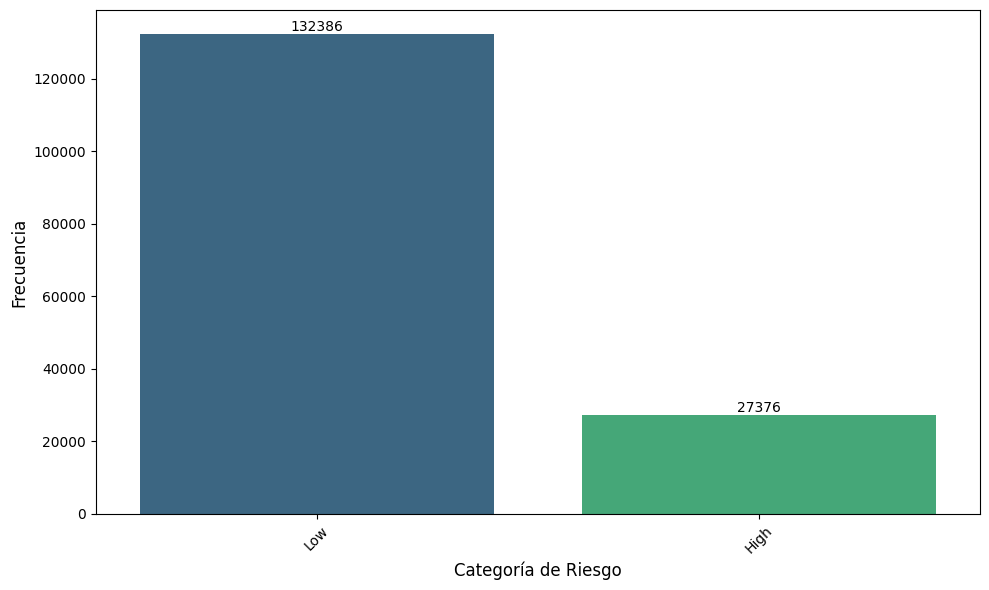

In [56]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='risk_level', palette='viridis', 
              order=train['risk_level'].value_counts().index)
plt.xlabel('Categoría de Riesgo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45)

# Añadir valores encima de cada barra
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
                
plt.tight_layout()
plt.show()

### Variables Categóricas

In [26]:
# Analizamos la cardinalidad de las variables categóricas
lista_cat = [
    'dc_dist', 'psa', 'hour', 'time_of_day',
    'day_of_week', 'week_of_year', 'month', 'season', 
    'is_holiday','ZCTA', 'sig', 'labels'
]

df_train_with_lag[lista_cat].nunique().sort_values(ascending = False)

ZCTA            55
week_of_year    52
hour            24
dc_dist         22
month           12
day_of_week      7
psa              6
labels           5
season           4
time_of_day      3
is_holiday       2
sig              2
dtype: int64

#### Hour

Notamos que la mayoría de crímenes sucenden durante el día, puntualmente entre 10am y las 6pm, lo cual hace sentido porque justamente es en estas horas donde hay mayor actividad poblacional.

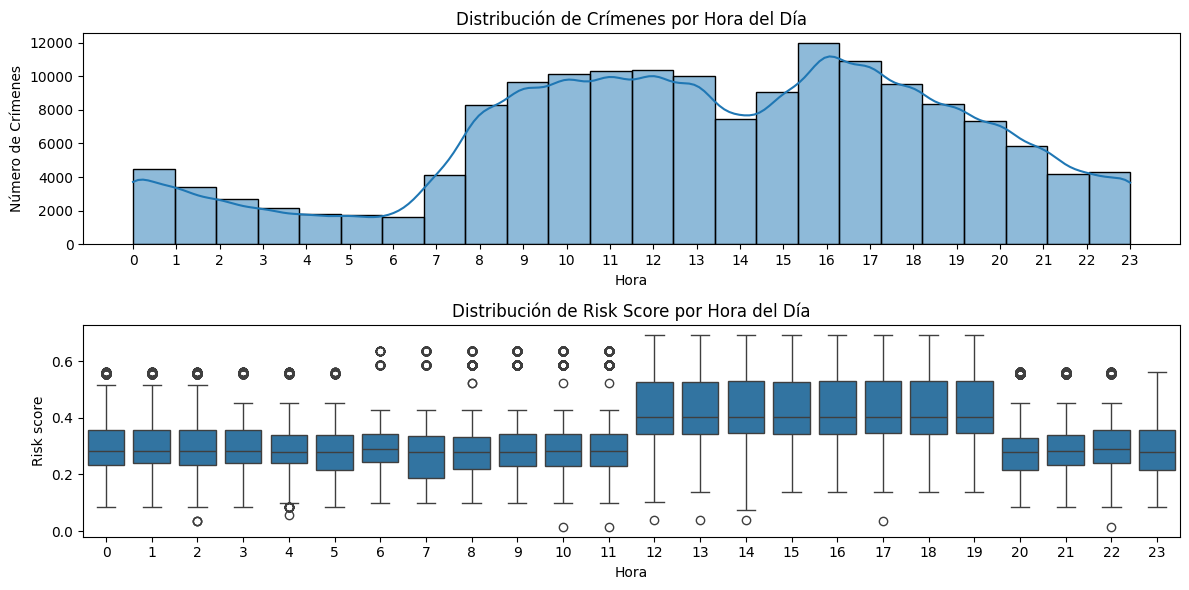

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))  # 2 filas, 1 columna

# Primer gráfico: histograma de crímenes por hora
sns.histplot(data=train, x='hour', bins=24, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Crímenes por Hora del Día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Número de Crímenes')
axes[0].set_xticks(range(0, 24))

# Segundo gráfico: boxplot de risk_score por hora
sns.boxplot(data=train, x='hour', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por Hora del Día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Risk score')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()  # Ajusta para que no se monten los títulos y etiquetas
plt.show()

In [28]:
chi2_cramersv(df = train, target='risk_level', cat_vars=['hour'])

,variable,p_value,cramers_v
0,hour,0.0,0.377524


#### Time of Day

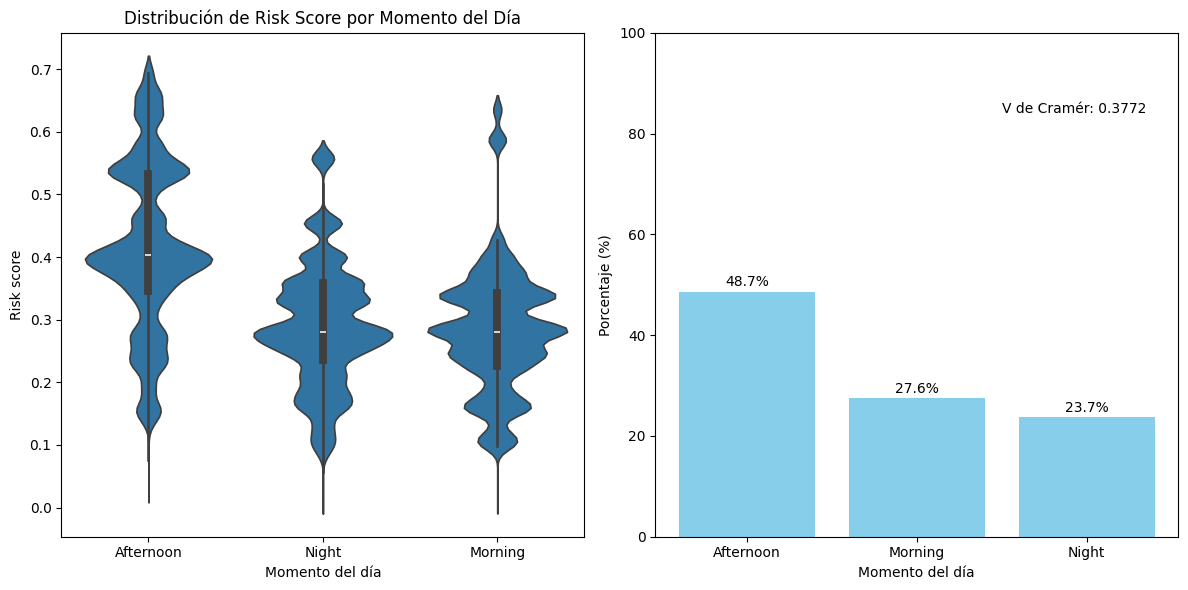

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 2 filas, 1 columna

# Primer gráfico: violinplot de risk_score por momento del día
sns.violinplot(data=train, x='time_of_day', y='risk_score', ax=axes[0])
axes[0].set_title('Distribución de Risk Score por Momento del Día')
axes[0].set_xlabel('Momento del día')
axes[0].set_ylabel('Risk score')

# Segundo gráfico: porcentaje de crímenes por momento del día con V de Cramér
counts = train['time_of_day'].value_counts(normalize=True) * 100
bars = axes[1].bar(counts.index, counts.values, color='skyblue')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('Momento del día')
axes[1].set_ylim(0, 100)

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)

# Añadir texto V de Cramér
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['time_of_day'])
axes[1].text(1.50, 84, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)

plt.tight_layout()
plt.show()

#### Dc_District 

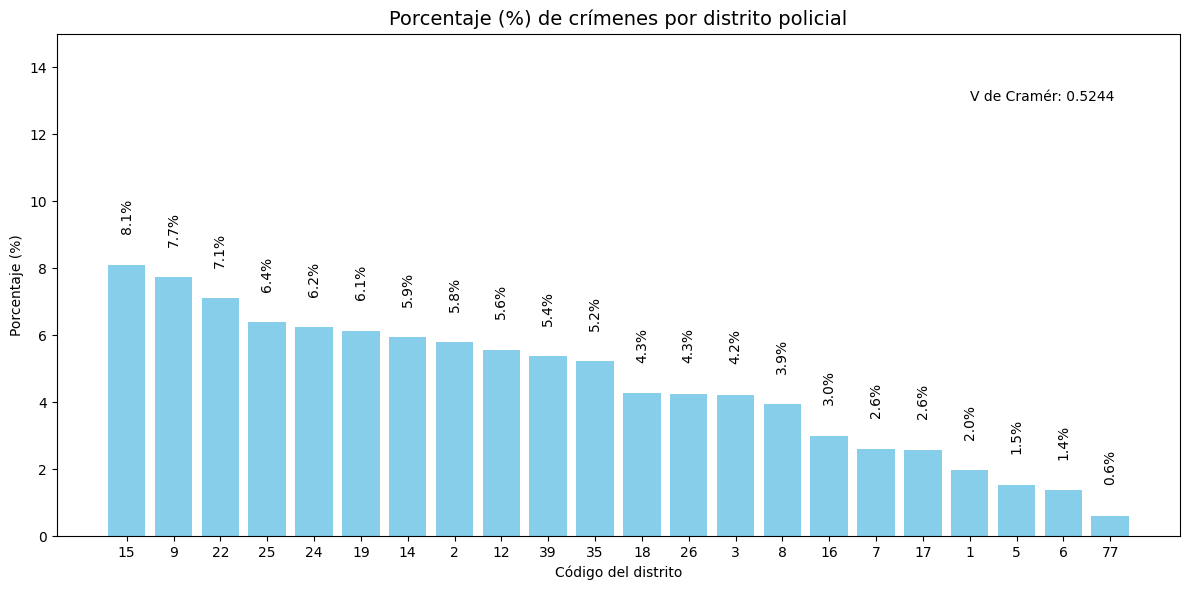

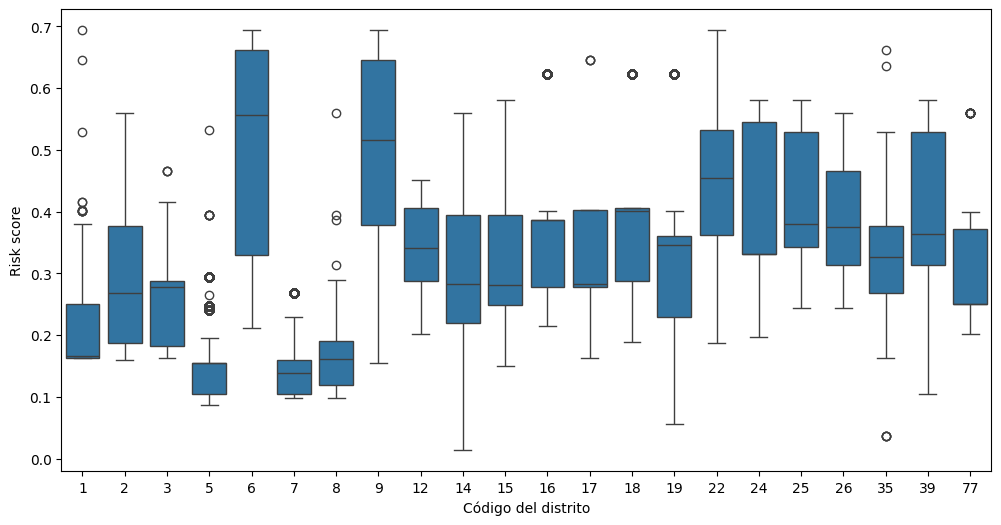

In [66]:
# Crear gráfico
plt.figure(figsize=(12,6))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Código del distrito')
plt.ylim(0, 15)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-4, 13, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='dc_dist', y = 'risk_score')
plt.xlabel('Código del distrito')
plt.ylabel('Risk score')
plt.show()

# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['dc_dist'])

# Porcentajes
counts = train['dc_dist'].value_counts(normalize=True) * 100

In [67]:
# Se procederá a hacer una agrupación con base en la media de nuestra variable target
target_mean = train.groupby('dc_dist')['risk_score'].agg(['mean']).reset_index().sort_values(by = 'mean', ascending=False)

thresholds = {
    'Rojo': 0.5,     # >= 0.4
    'Naranja': 0.4, # 0.25 - 0.4
    'Amarillo': 0.3, 
    'Verde': 0.20      # < 0.15
}

# La lógica de agrupación 
def categorizar_dc_dist(mean_value):
    if mean_value >= thresholds['Rojo']:
        return 'Rojo'
    elif mean_value >= thresholds['Naranja']:
        return 'Naranja'
    elif mean_value >= thresholds['Amarillo']:
        return 'Amarillo'
    else:
        return 'Verde'
    
# Se crea nueva columna 
target_mean['dc_dist_grouped'] = target_mean['mean'].apply(categorizar_dc_dist)

In [68]:
# Merge con la data inicial
train = train.merge(target_mean[['dc_dist', 'dc_dist_grouped']], how='left', on = 'dc_dist')

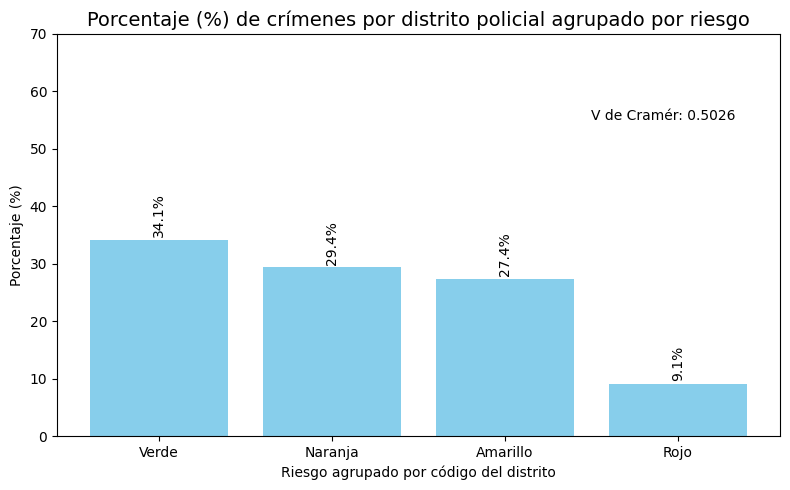

In [73]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['dc_dist_grouped'])

# Porcentajes
counts = train['dc_dist_grouped'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial agrupado por riesgo', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Riesgo agrupado por código del distrito')
plt.ylim(0, 70)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-1.5, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

#### Psa

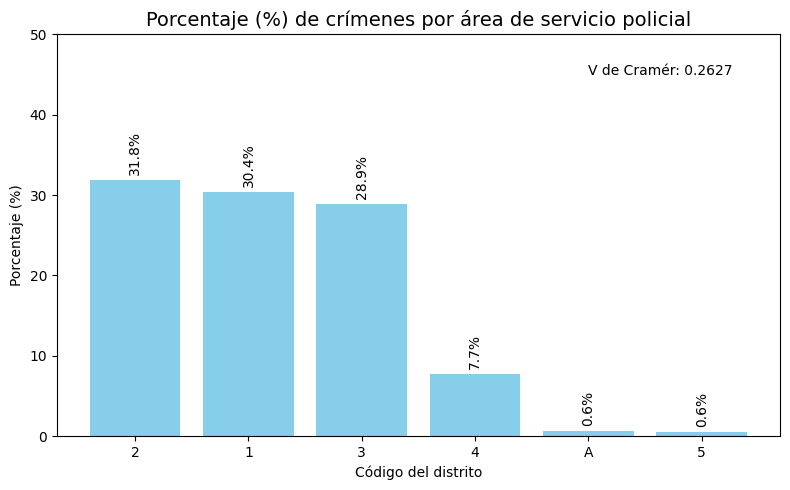

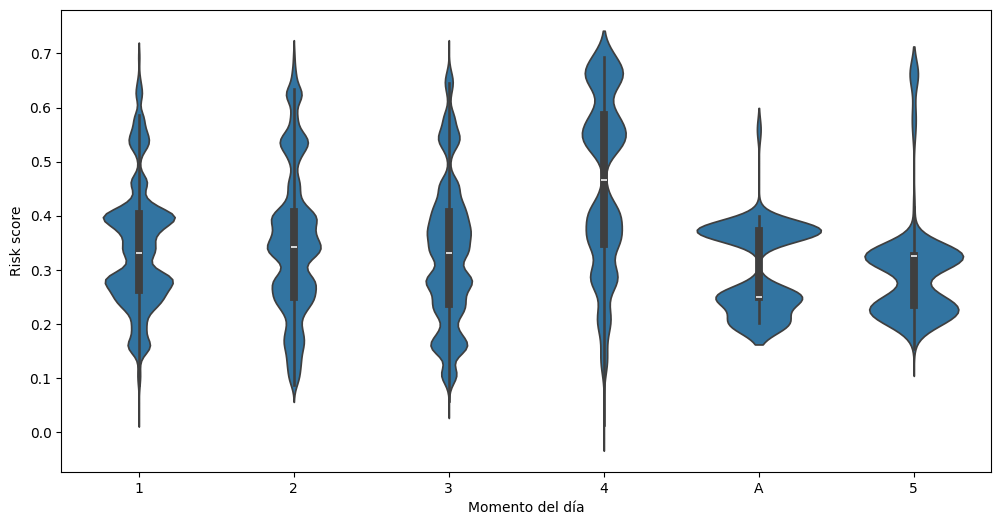

In [35]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['psa'])

# Porcentajes
counts = train['psa'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por área de servicio policial', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Código del distrito')
plt.ylim(0, 50)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-2.0, 45, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='psa', y = 'risk_score')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

#### Month

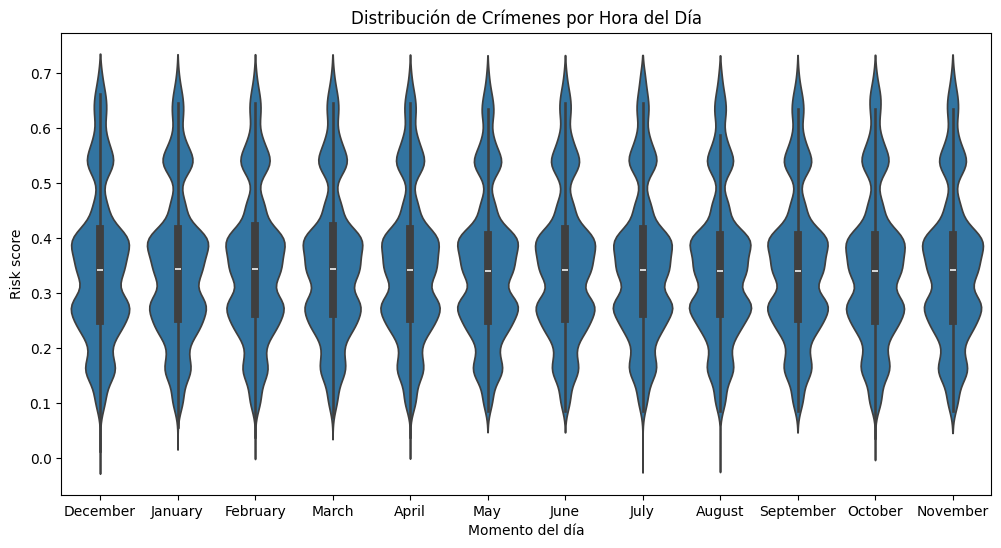

In [ ]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='month', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

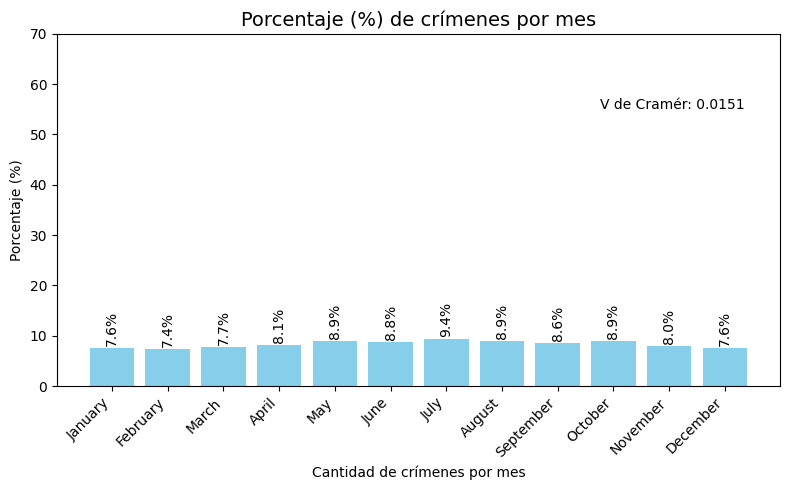

In [38]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['month'])

order = list(calendar.month_name)[1:]

# Porcentajes
counts = train['month'].value_counts(normalize=True) * 100
counts = counts.reindex(order).dropna()

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por mes', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Cantidad de crímenes por mes')
plt.ylim(0, 70)
plt.xticks(rotation=45, ha='right')
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-3.25, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10,)
plt.tight_layout()
plt.show()

#### Season

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22308\1084258390.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(counts.index, rotation=45, ha='right')


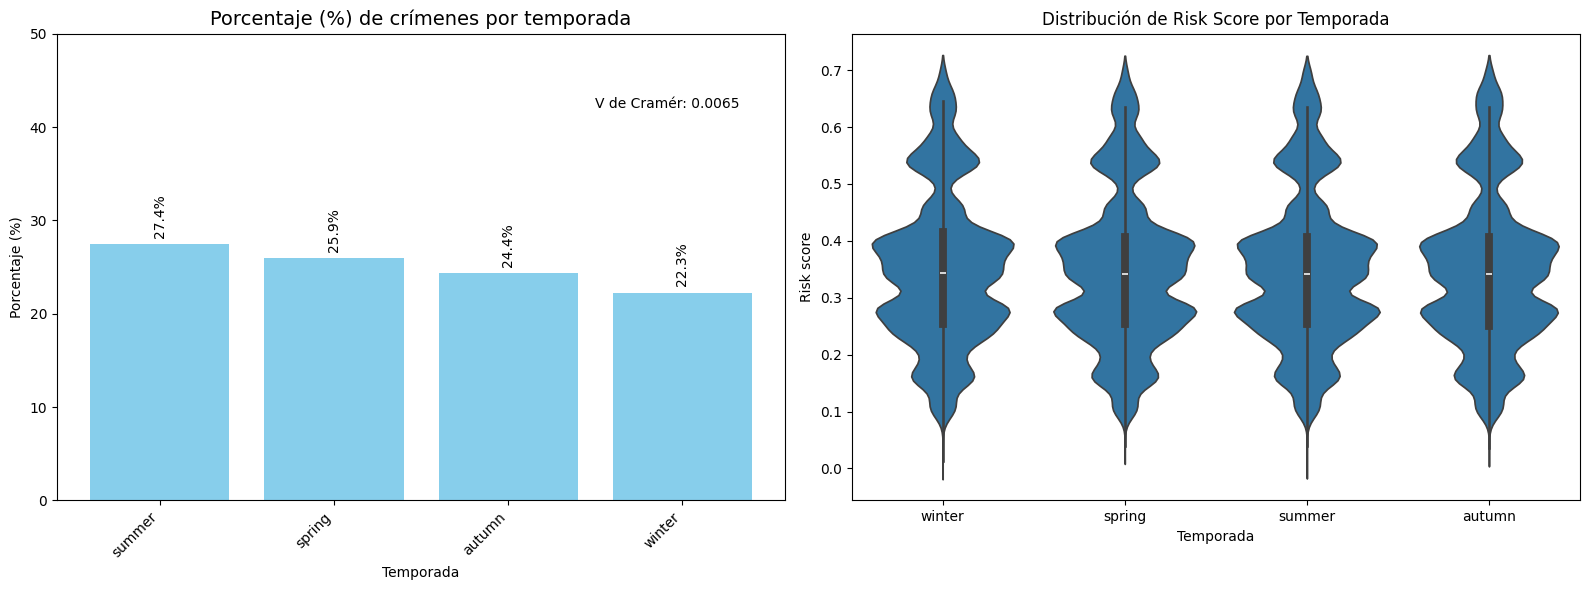

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['season'])

counts = train['season'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por temporada', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Temporada')
axes[0].set_ylim(0, 50)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1.50, 42,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='season', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por Temporada')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Week day

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22308\2794997047.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(counts.index, rotation=45, ha='right')


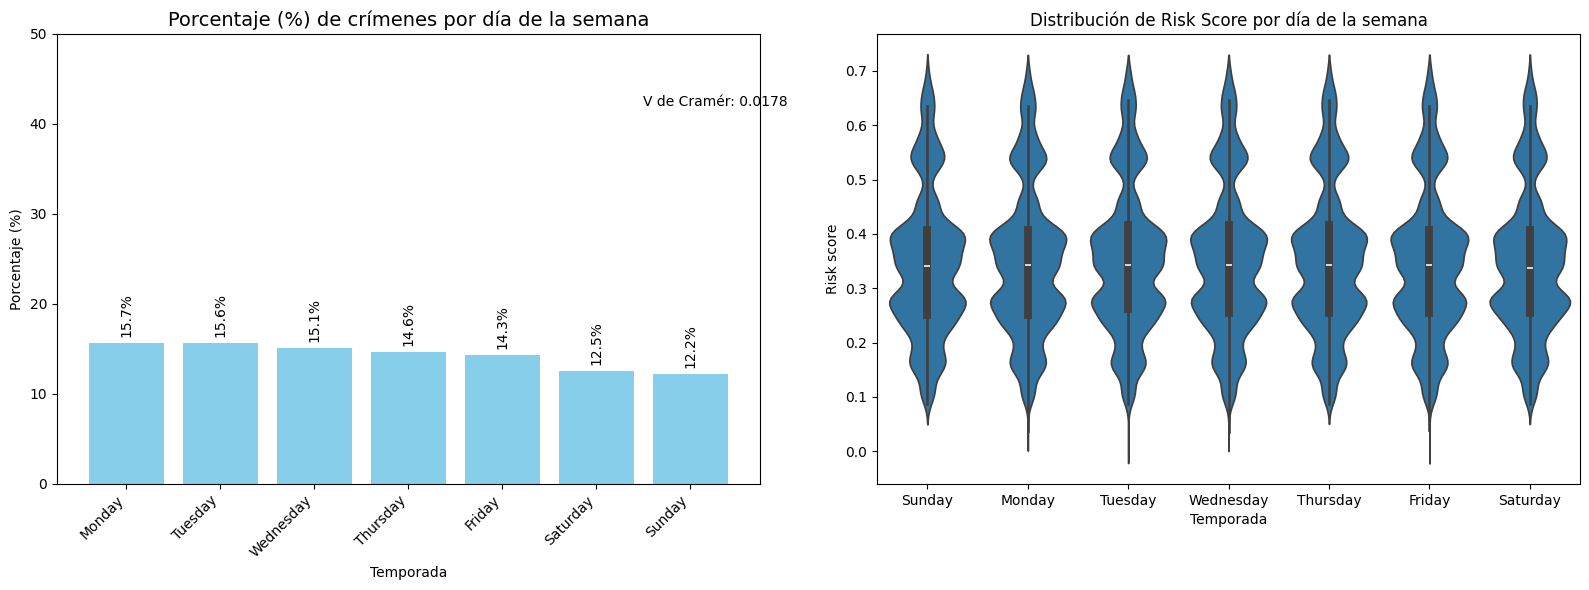

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['day_of_week'])

counts = train['day_of_week'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por día de la semana', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Temporada')
axes[0].set_ylim(0, 50)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1.50, 42,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='day_of_week', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por día de la semana')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Holiday 

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22308\2540792089.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(counts.index, rotation=45, ha='right')


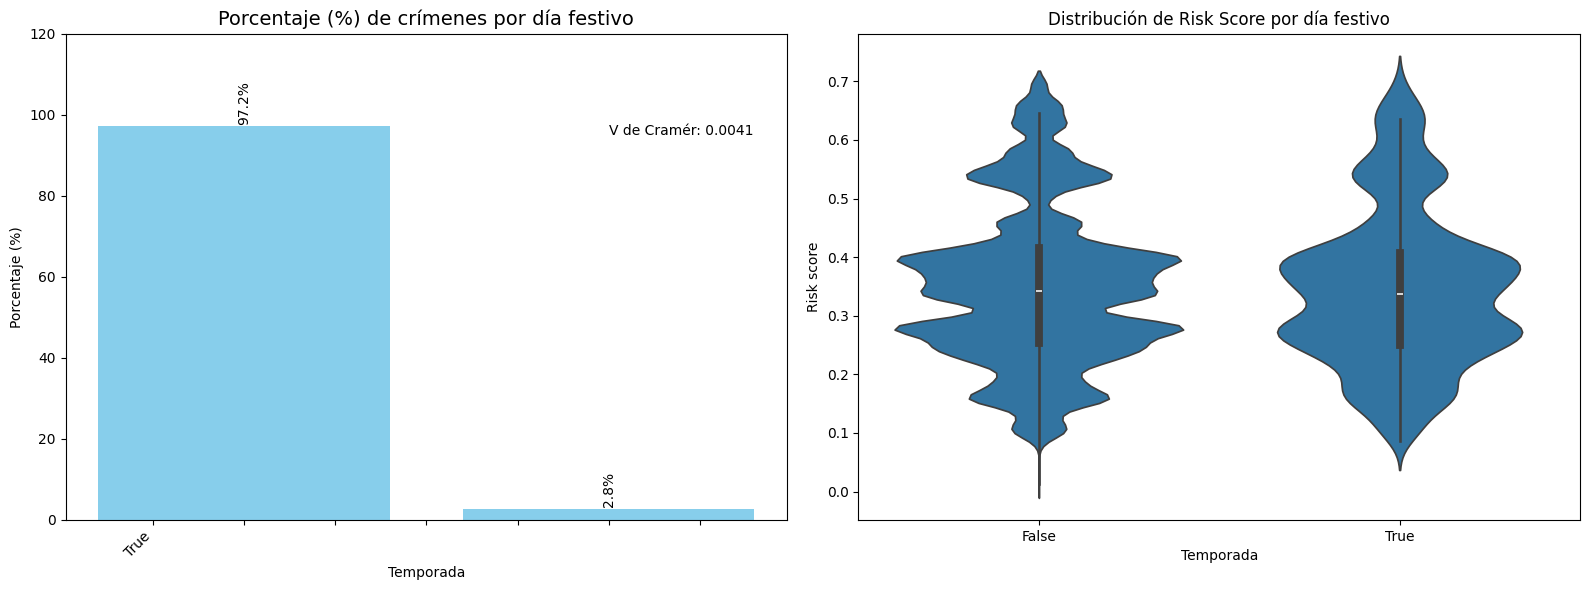

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['is_holiday'])

counts = train['is_holiday'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por día festivo', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Temporada')
axes[0].set_ylim(0, 120)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1, 95,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='is_holiday', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por día festivo')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Significancia de Autocorrelacion Local

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22308\876724720.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(counts.index, rotation=45, ha='right')


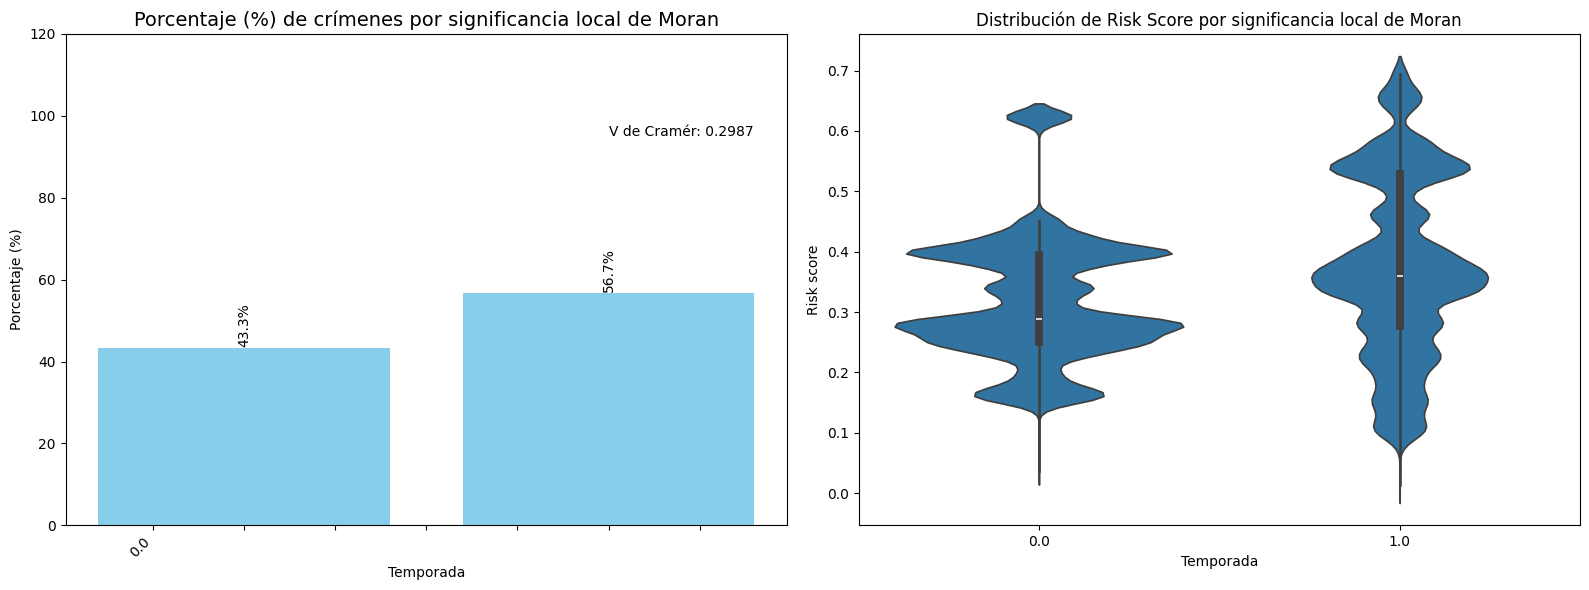

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['sig'])

counts = train['sig'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por significancia local de Moran', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Temporada')
axes[0].set_ylim(0, 120)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1, 95,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='sig', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por significancia local de Moran')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Dirección de Significancia

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_22308\2510803964.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(counts.index, rotation=45, ha='right')


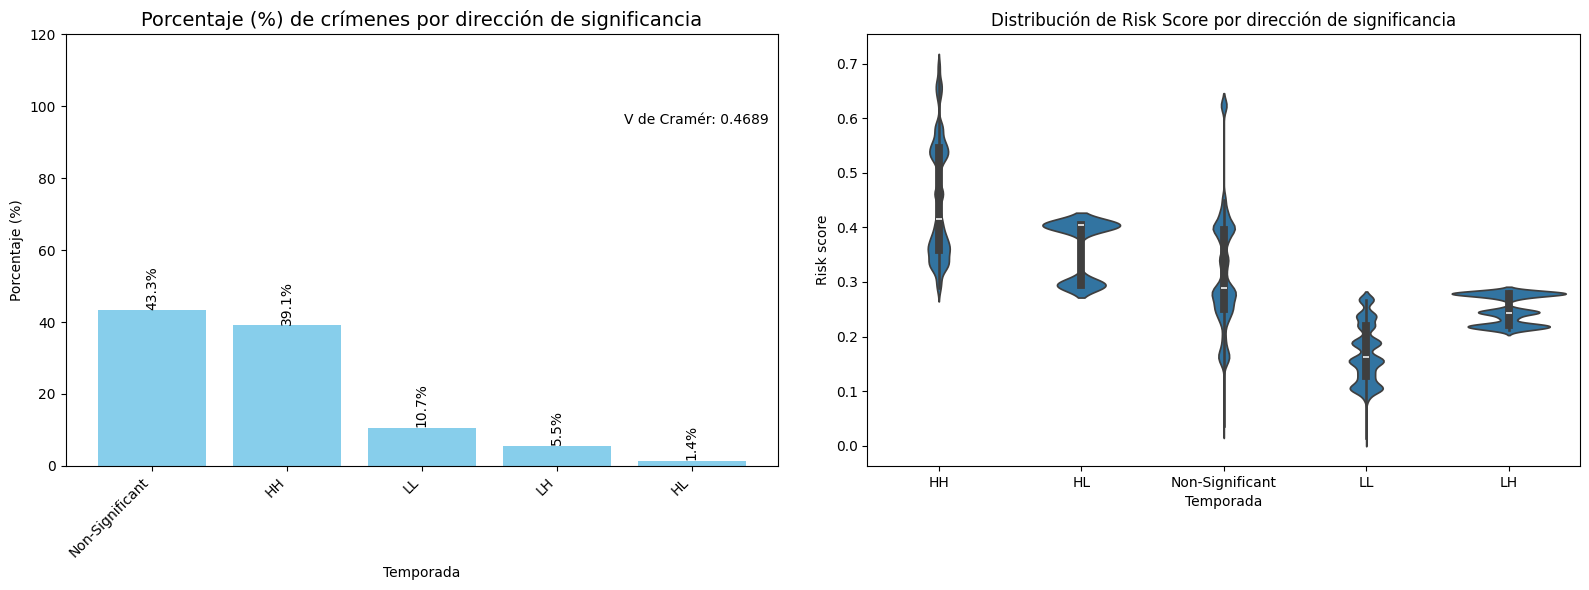

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['labels'])

counts = train['labels'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por dirección de significancia', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Temporada')
axes[0].set_ylim(0, 120)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1.5, 95,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='labels', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por dirección de significancia')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### ZCTA

In [62]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['ZCTA'])
cramerV

,variable,p_value,cramers_v
0,ZCTA,0.0,0.716025


## Variables Numéricas

La mayoría de variables numéricas que hay corresponden a estadísticas socioeconómicas de las áreas ZCTA, por lo que se procede a aplicar la técnica de WOE para tramificar dichas variables. Para ello, es primero importante hacer el split entre train y test:

In [79]:
X = train.drop(['risk_score', 'risk_level'], axis = 1)
y = train['risk_level']
y = (y == 'High').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Gini Index

In [80]:
variable = 'GiniIndex'

optb = OptimalBinning(name=variable, dtype="numerical", solver="cp")
# Una vez definido podemos pasar a estimarlo
optb.fit(X_train[variable], y_train)
optb.splits

binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.49)",54271,0.485564,50075,4196,0.077316,0.903262,0.290454,0.035121
1,"[0.49, 0.52)",23888,0.213727,20152,3736,0.156397,0.109159,0.002456,0.000307
2,"[0.52, 0.54)",18987,0.169877,11728,7259,0.382314,-1.096392,0.276743,0.032958
3,"[0.54, inf)",14623,0.130832,10663,3960,0.270806,-0.585593,0.053669,0.006614
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,111769,1.000000,92618,19151,0.171344,,0.623322,0.075000


In [ ]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

In [84]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

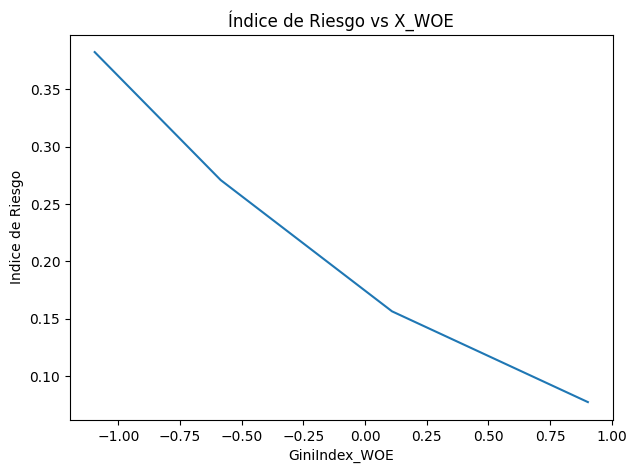

<Figure size 700x500 with 0 Axes>

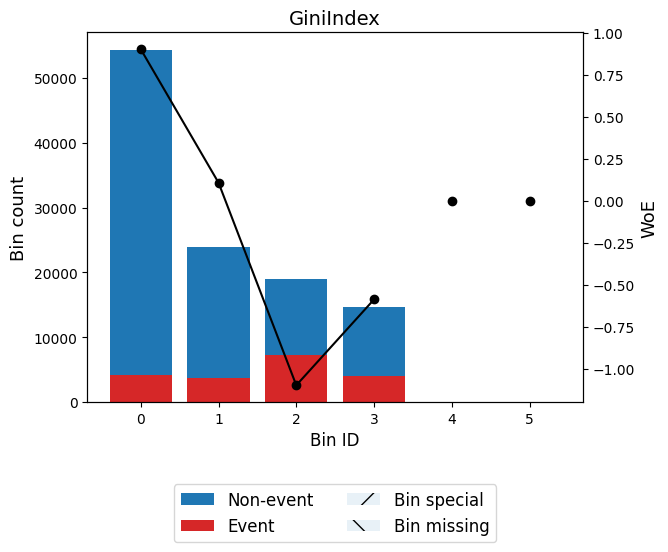

In [95]:
# Crear el primer gráfico por separado
plt.figure(figsize=(7, 5))
plt.plot(pd.crosstab(X_train[new_variable_name].values, y_train, normalize=0).iloc[:,1])
plt.xlabel(new_variable_name)
plt.ylabel("Indice de Riesgo")
plt.title("Índice de Riesgo vs X_WOE")
plt.show()

# Crear el segundo gráfico por separado
plt.figure(figsize=(7, 5))
binning_table.plot(metric="woe")

In [96]:
train.columns

Index(['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'id',
       'time_of_day', 'day_of_week', 'week_of_year', 'month', 'season',
       'is_holiday', 'crimeType', 'ZCTA', 'area_mile2', 'lon', 'lat',
       'population', 'white_race', 'black_race', 'asian_race', 'latino_race',
       'density_mile2', 'median_income', 'mean_income', 'total_households',
       'household_25k_or_less', 'household_25k_to_50k',
       'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
       'risk_score', 'risk_level', 'geometry', 'risk_score_lag', 'sig',
       'labels'],
      dtype='object')

### Hogares con ingresos superiores a los 150k

In [110]:
optb, binning_table = optimal_binning(X_train, y_train, 'latino_race')
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1822.00)",34972,0.312895,24821,10151,0.290261,-0.682011,0.178726,0.021918
1,"[1822.00, 2563.50)",16211,0.145040,14122,2089,0.128863,0.33492,0.014534,0.001808
2,"[2563.50, 21586.00)",42998,0.384704,41810,1188,0.027629,1.984736,0.772838,0.083335
3,"[21586.00, inf)",17588,0.157360,11865,5723,0.325392,-0.847029,0.144612,0.017555
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,111769,1.000000,92618,19151,0.171344,,1.110710,0.124615


# Modelos de Clasificación

In [112]:
# Definimos la variable objetivo
target = "risk_level"

# Definimos las features (flexible para iterar)
features = [
    "lon", "lat",              
    "GiniIndex_WOE",
    "sig", 
    "labels"        
]

X_train_model = X_train[features].copy()

# Aseguramos que el tipo de dato se cumpla
num_features = X_train_model.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
cat_features = X_train_model.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Variables numéricas:", num_features)
print("Variables categóricas:", cat_features)

Variables numéricas: ['lon', 'lat', 'GiniIndex_WOE', 'sig']
Variables categóricas: ['labels']


In [113]:
# Transformadores
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # 👈 rellena NaN en numéricas
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # 👈 rellena NaN en categóricas
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), num_features),   # Estandarizar numéricas
#         ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)  # One-hot en categóricas
#     ]
# )

### Random Forest

In [114]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    class_weight="balanced_subsample",   # útil si hay desbalance
    n_jobs=-1
)

In [115]:
# Pipeline completo
# clf = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("model", rf_model)
# ])

# Construir pipeline con SMOTE + preprocesador + modelo
clf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),   # encoding y escalado
    ("smote", SMOTE(random_state=42)), # oversampling solo en train
    ("model", rf_model)
])

In [116]:
clf.fit(X_train_model, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lon', 'lat',
                                                   'GiniIndex_WOE', 'sig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['labels'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [117]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # probabilidades clase positiva

In [118]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     39694
           1       0.60      0.80      0.68      8207

    accuracy                           0.87     47901
   macro avg       0.78      0.84      0.80     47901
weighted avg       0.89      0.87      0.88     47901



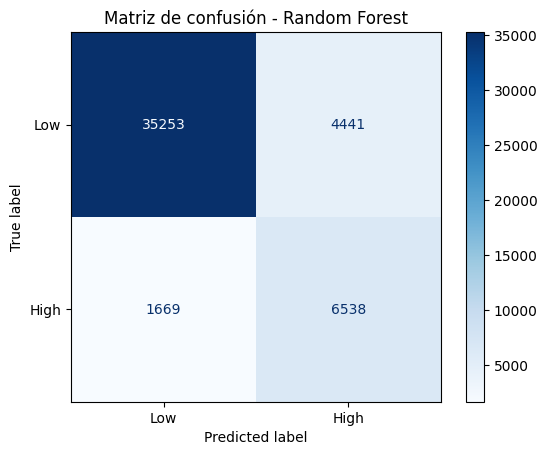

In [119]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión - Random Forest")
plt.show()


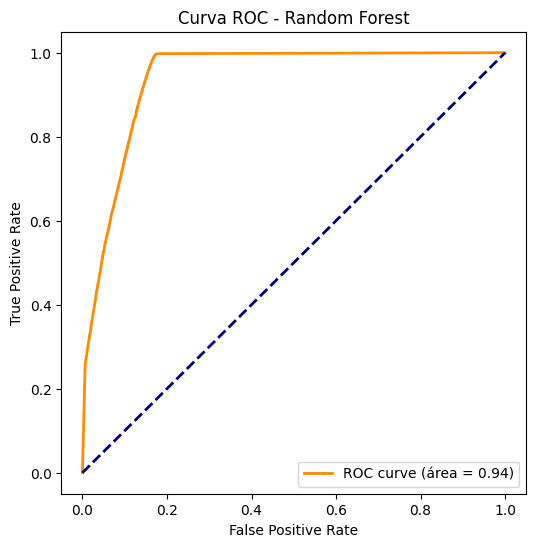

In [120]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (área = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()

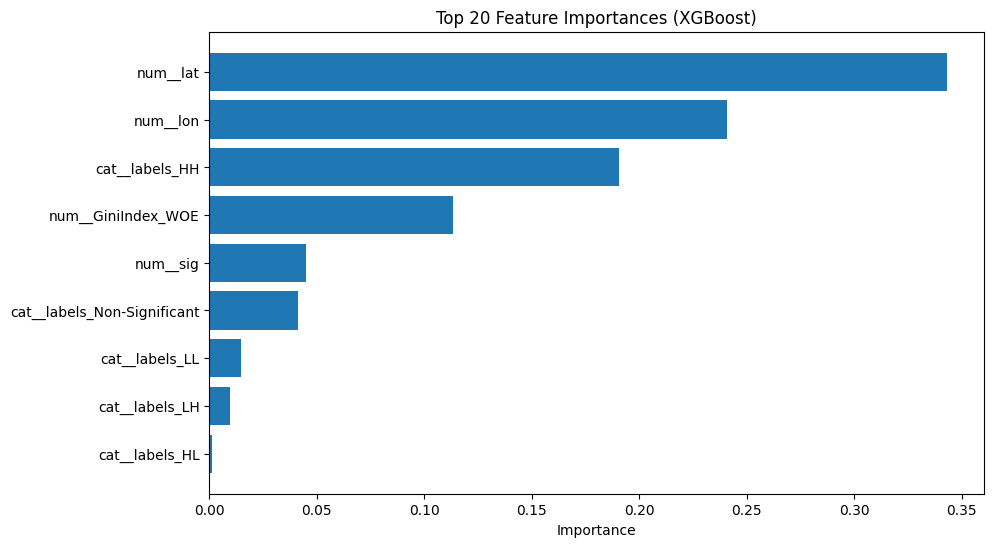

In [121]:
# 1. Recuperar el modelo entrenado
rf_model = clf.named_steps["model"]

# 2. Recuperar nombres de columnas después del preprocesador
#    - numéricas pasan directas
#    - categóricas se expanden con OneHotEncoder
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

# 3. Importancias desde el modelo
importances = rf_model.feature_importances_

# 4. Crear DataFrame ordenado
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# 5. Graficar
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"][:20], feat_imp["importance"][:20])  # Top 20
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

## XGBoost

In [239]:
# Calcular ratio para manejar el desbalance
neg, pos = np.bincount(y_train)  # cuenta 0s y 1s en train
scale_pos_weight = neg / pos     # cuanto más alto, más peso a la clase minoritaria

xgb_model = XGBClassifier(
    n_estimators=500,         # más árboles (puedes tunear)
    learning_rate=0.05,       # paso de aprendizaje
    max_depth=6,              # profundidad de los árboles
    subsample=0.8,            # muestreo de filas
    colsample_bytree=0.8,     # muestreo de columnas
    random_state=42,
    n_jobs=-1,
    # scale_pos_weight=scale_pos_weight,  # balanceo de clases
    eval_metric="logloss",    # métrica interna
    use_label_encoder=False   # evita warning en versiones viejas
)

In [240]:
# Pipeline completo
# clf = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("model", xgb_model)
# ])

# Construir pipeline con SMOTE + preprocesador + modelo
clf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),   # encoding y escalado
    ("smote", SMOTE(random_state=42)), # oversampling solo en train
    ("model", xgb_model)
])

In [ ]:
# === Definir los parámetros para el grid search ===
grid_param = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

In [ ]:
# === Configurar GridSearch ===
from sklearn.model_selection import GridSearchCV
model_grid = GridSearchCV(
    estimator=clf,
    param_grid=grid_param,
    # scoring='recall_macro',  # Importante para multiclase
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [241]:
clf.fit(X_train, y_train)

C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [21:53:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lon', 'lat', 'sig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['dc_dist_grouped',
                                                   'labels'])])),
                ('smot...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [242]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # probabilidades clase positiva

In [243]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90     39716
           1       0.54      0.99      0.70      8213

    accuracy                           0.85     47929
   macro avg       0.77      0.91      0.80     47929
weighted avg       0.92      0.85      0.87     47929



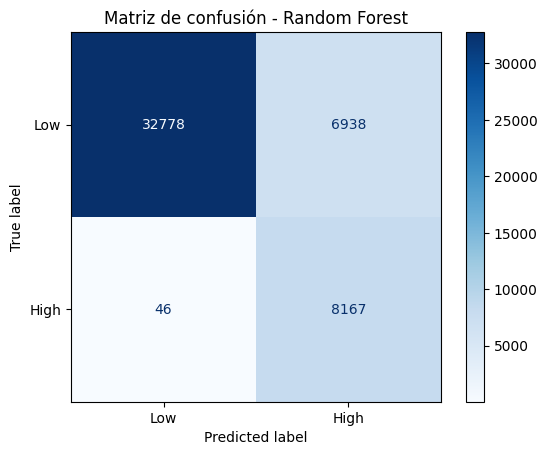

In [244]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión - Random Forest")
plt.show()

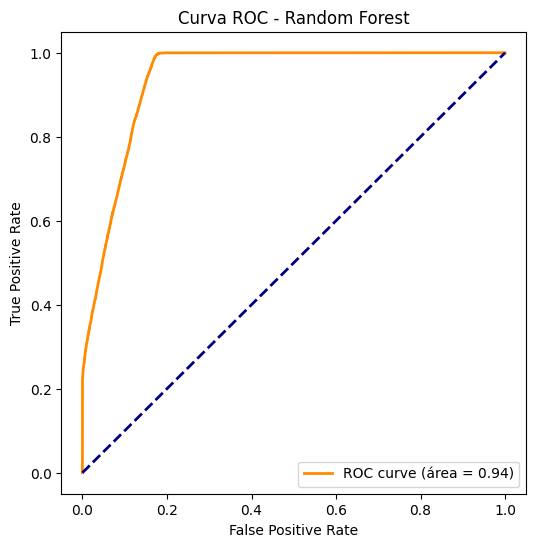

In [245]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (área = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()

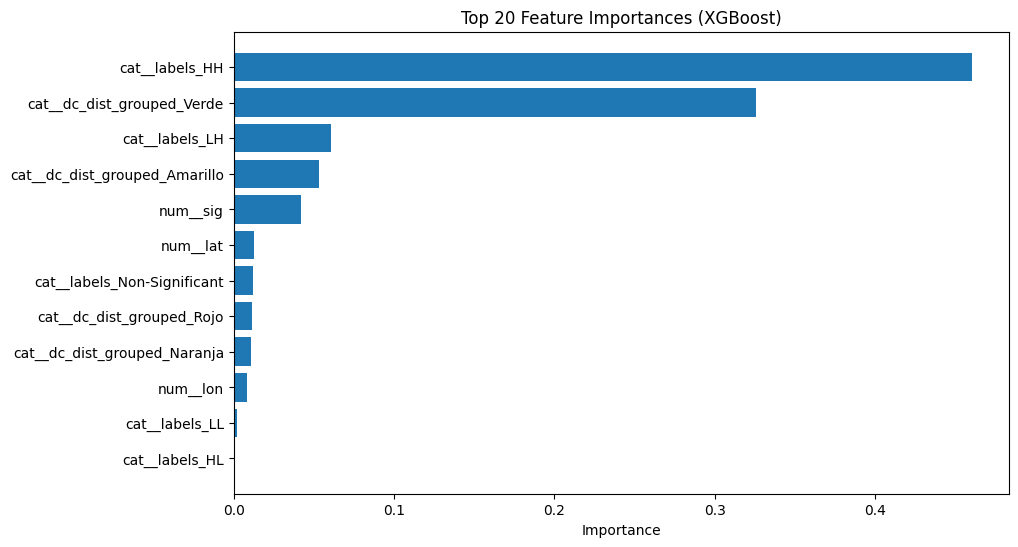

In [246]:
# 1. Recuperar el modelo entrenado
xgb_model = clf.named_steps["model"]

# 2. Recuperar nombres de columnas después del preprocesador
#    - numéricas pasan directas
#    - categóricas se expanden con OneHotEncoder
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

# 3. Importancias desde el modelo
importances = xgb_model.feature_importances_

# 4. Crear DataFrame ordenado
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# 5. Graficar
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"][:20], feat_imp["importance"][:20])  # Top 20
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()